In [16]:
import numpy as np
import trackpy as tp
import matplotlib.pyplot as plt
import zarr
from pathlib import Path

#input_dir = Path("/mnt/NAS-Ebanaru/sasaki/MTsingleBeads/beads1um/20260122/exp001")
#input_dir = Path("/Volumes/data/Sasaki/MTsingleBeads/beads8um/20260609/beads8um_crop")
input_dir = Path("/Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um001")

beads_path = input_dir / "beads.zarr"
za = zarr.open_array(beads_path, read_only=True)
beads = za[:]
output = input_dir

Text(0.5, 1.0, 'Histogram of intensity')

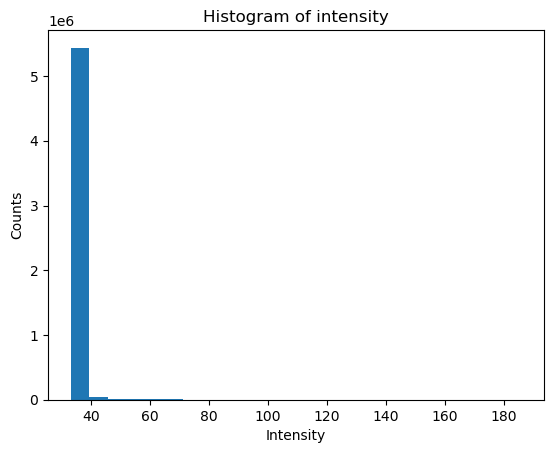

In [19]:
data_for_hist = beads[beads.shape[0]-1].reshape(-1)
bins = np.histogram_bin_edges(data_for_hist, bins = 'sturges')
_=plt.hist(beads[beads.shape[0]-1].reshape(-1), bins =bins)

#plt.xlim(0,30)
#plt.yscale('log')å
plt.xlabel('Intensity')
plt.ylabel('Counts')
plt.title('Histogram of intensity')

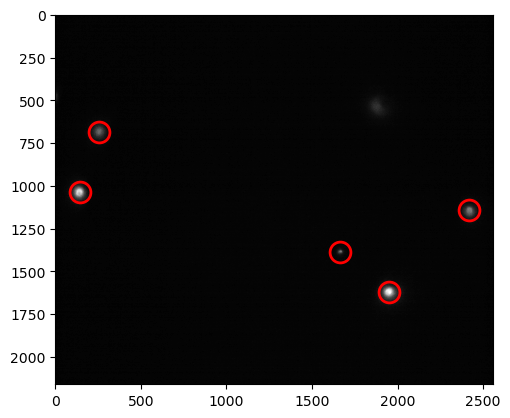

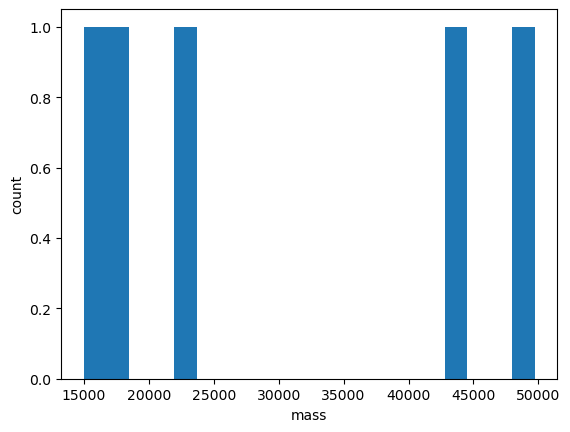

In [23]:
diameter = 5
scale = 0.11
time_inerval = 4 #timescle

minmass = 150
threshold = 5

pxdiameter =int(diameter/scale)
if pxdiameter % 2 ==0:
    pxdiameter = pxdiameter + 1


f = tp.locate(beads[0], pxdiameter, minmass = minmass, threshold=threshold)
tp.annotate(f, beads[0])

fig, ax = plt.subplots()
ax.hist(f['mass'], bins=20)
# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count');

#tp.subpx_bias(f)

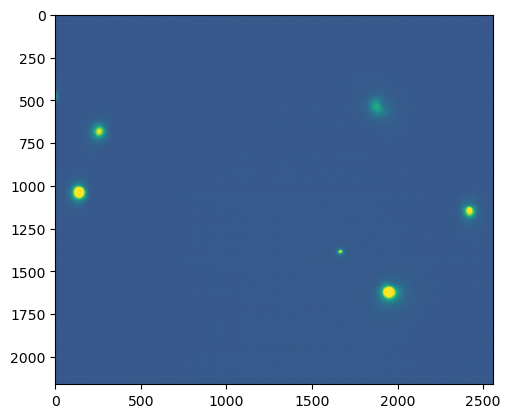

In [24]:
plt.imshow(beads[0], vmin=10, vmax = beads[0].max()*0.5)

In [25]:
print('max_frame:',beads.shape[0],'\n')
f = tp.batch(beads, pxdiameter, minmass = minmass, threshold=threshold)

Frame 201: 7 features


In [26]:
cargo_velocity = 5.0 #大体の輸送速度（trackingのdistanceを計測するために使うので大体でいい）
distance = int(cargo_velocity * time_inerval / scale)

print('max_frame:',beads.shape[0],'\n')
tracks = tp.link(f, distance, memory=100)
t1 = tp.filter_stubs(tracks)

Frame 201: 7 trajectories present.


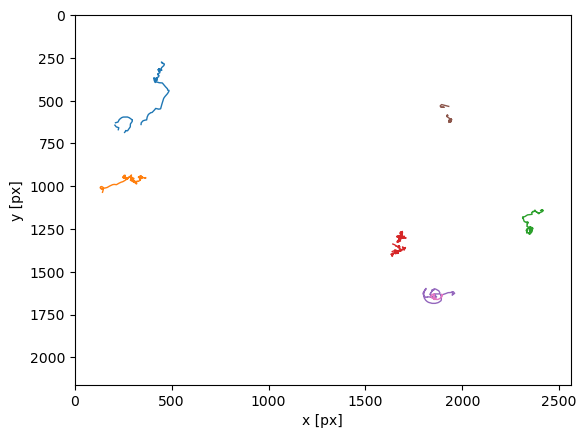

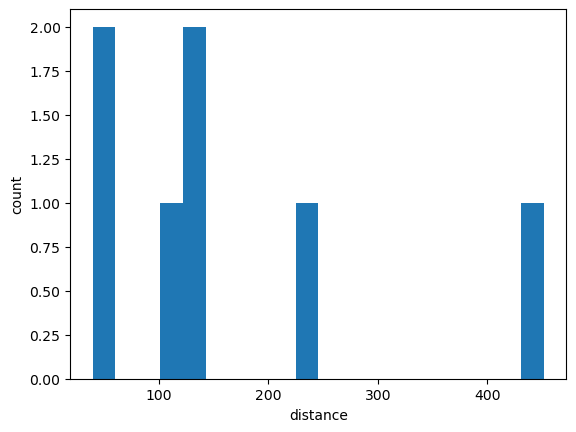

In [27]:
threshold = 20
import os
import sys
sys.path.append(os.path.abspath(".."))
from libs import remove_fixed as rf 

t2 = rf.remove_fixed(t1, threshold)

plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(t2);

tracks_dist2 = rf.cal_dis(t2)

fig, ax = plt.subplots()
ax.hist(tracks_dist2["distance"], bins=20)

# Optionally, label the axes.
ax.set(xlabel='distance', ylabel='count');
os.makedirs(output, exist_ok=True)
#os.makedirs(output2, exist_ok=True)
t2.to_csv(f"{output}/beads_tracks.csv", index=False)
#t2.to_csv(f"{output2}/beads_tracks.csv", index=False)

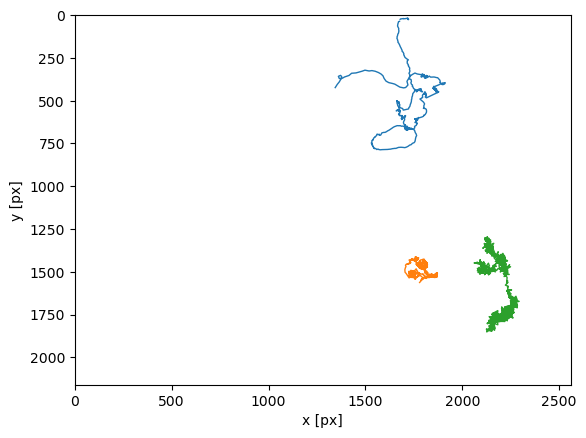

In [29]:
import pandas as pd

df = pd.read_csv("/Volumes/data/Sasaki/MTsingleBeads/beads5um/20260715/beads5um002/beads_tracks.csv")

plt.figure()
plt.xlim((0, 2560))
plt.ylim((0, 2160))
tp.plot_traj(df);